In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
#df = pd.read_csv(r"C:\Users\hemal\OneDrive\Desktop\Python Hackhathon\team9_PyCoders_PythonHackathon_MAY2026\clean.csv")

In [ ]:
df = pd.read_csv(
    r'C:\Users\hemal\OneDrive\Desktop\Python Hackhathon\team9_PyCoders_PythonHackathon_MAY2026\clean.csv',
    parse_dates=['time']
)

1. Can insulin delivery effectiveness be evaluated using post-insulin glucose response?

Markers Chosen

bolus_volume_delivered
glucose
time
Why?

This measures how effective insulin delivery is over time.
Medical Influence
Poor response may indicate:
Insulin resistance
Delayed dosing
Incorrect carb counting
Supporting Evidence

Analyze:

Glucose before and after bolus events


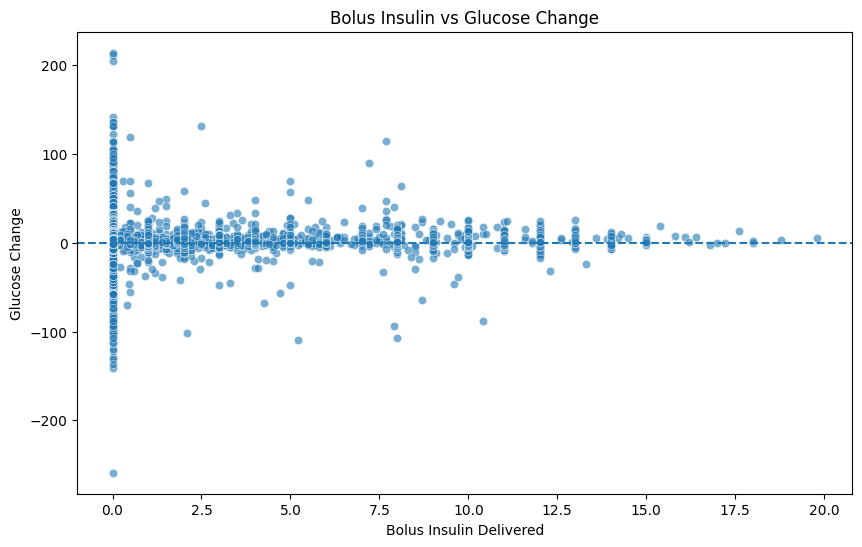

In [16]:
# Sort data
df = df.sort_values(['Patient_ID', 'time'])

# Calculate glucose change within patient
df['glucose_change'] = (
    df.groupby('Patient_ID')['glucose']
      .diff()
)

# Plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='bolus_volume_delivered',
    y='glucose_change',
    alpha=0.6
)

plt.axhline(0, linestyle='--')

plt.title("Bolus Insulin vs Glucose Change")
plt.xlabel("Bolus Insulin Delivered")
plt.ylabel("Glucose Change")

plt.show()

Prescriptive Analysis Recommendation

Analysis: Bolus Insulin vs Glucose Change

Observation from Chart

Most glucose changes are clustered near 0 after insulin delivery.

Several extreme positive and negative glucose changes are visible.
Low bolus insulin doses show high variability in glucose response.
Higher bolus insulin doses appear to stabilize glucose changes closer to normal ranges.

2. Should alerts be triggered when heart rate and glucose simultaneously become abnormal?

Markers Chosen

heart_rate
glucose

Why?

Combined abnormalities may indicate severe physiological stress.

Medical Influence

Could help detect:

Hypoglycemia
Stress-induced hyperglycemia
Supporting Evidence
Find simultaneous anomalies.


                      time  glucose  calories  heart_rate  steps  basal_rate  \
295010 2018-06-13 19:30:00    271.0     17.79      104.54  124.0       0.075   
295011 2018-06-13 19:35:00    270.0     10.63      100.15   21.0       0.075   
295014 2018-06-13 19:50:00    242.0     24.31      103.96  510.0       0.075   
295015 2018-06-13 19:55:00    232.0     25.44      109.41  505.0       0.075   
295032 2018-06-13 21:20:00     64.0     13.93      105.95    0.0       0.000   

        bolus_volume_delivered  carb_input Patient_ID  Age Gender   Race  \
295010                     0.0         0.0  HUPA0001P   34   Male  Other   
295011                     0.0         0.0  HUPA0001P   34   Male  Other   
295014                     0.0         0.0  HUPA0001P   34   Male  Other   
295015                     0.0         0.0  HUPA0001P   34   Male  Other   
295032                     0.0         0.0  HUPA0001P   34   Male  Other   

        Average Sleep Duration (hrs)  Sleep Quality (1-10)  \


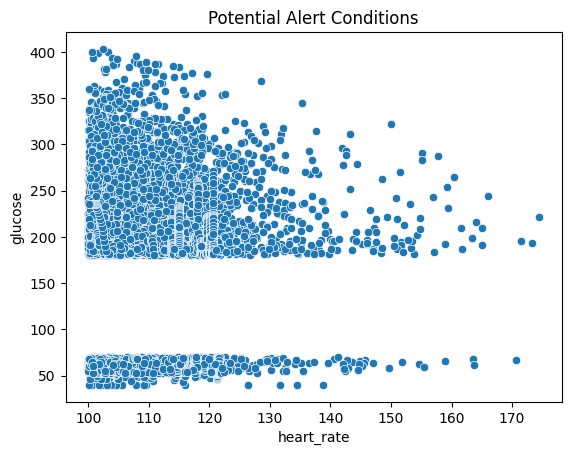

In [18]:
alerts = df[
   (df['heart_rate'] > 100) &
   ((df['glucose'] < 70) | (df['glucose'] > 180))
]


print(alerts.head())


sns.scatterplot(data=alerts, x='heart_rate', y='glucose')
plt.title("Potential Alert Conditions")
plt.show()


Prescriptive Analysis Recommendation

Analysis: Potential Alert Conditions (Heart Rate vs Glucose)

Observation from Chart

Many patients show extremely high glucose levels (180–400) combined with elevated heart rates.
A second cluster appears at low glucose levels (40–70), which may indicate hypoglycemia risk.
Higher heart rates are observed in both hyperglycemic and hypoglycemic conditions.
Several outlier patients show very high heart rate with abnormal glucose values, indicating possible emergency conditions.

3. Can personalized treatment recommendations be created using combined physiological markers?

Markers Chosen

glucose
heart_rate
steps
calories
basal_rate
bolus_volume_delivered

Why?

Combining all markers enables holistic patient monitoring.
Medical Influence

Supports:

Personalized insulin therapy
Lifestyle recommendations
Early intervention systems
Supporting Evidence
Use multivariable correlation analysis.


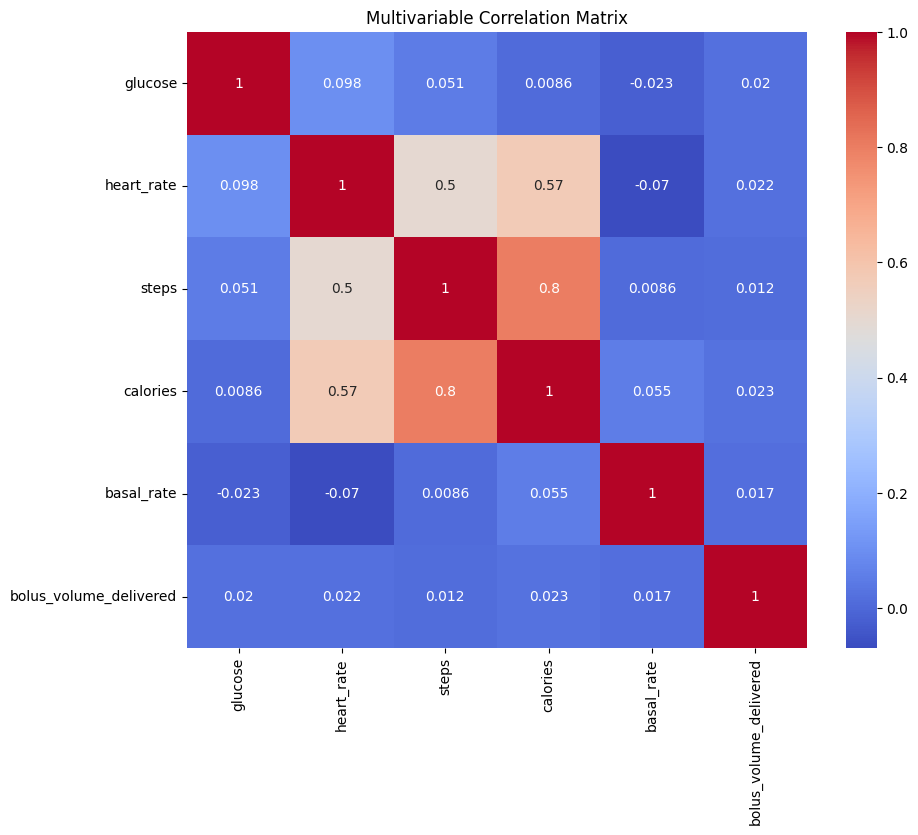

In [19]:
features = [
   'glucose',
   'heart_rate',
   'steps',
   'calories',
   'basal_rate',
   'bolus_volume_delivered'
]


corr = df[features].corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Multivariable Correlation Matrix")
plt.show()


Overall Key Finding

Glucose Is Multi-Factorial

The correlation matrix strongly suggests:

glucose is influenced by many interacting variables

no single biomarker strongly predicts glucose alone

This is one of the most important healthcare insights from your dataset.

Strong Overall Insight Statement for Notebook

“The multivariable correlation analysis revealed strong relationships between physical activity biomarkers such as steps and calories burned, while glucose showed weak direct correlation with individual biomarkers, including insulin delivery. These findings suggest that glucose regulation is highly multifactorial and influenced by complex interactions among activity, metabolism, insulin response, and patient-specific physiological factors. The results support the need for personalized, multi-factor diabetes monitoring and predictive healthcare systems.”

Prescriptive Analysis Recommendation

Analysis: Multivariable Correlation Matrix

Observation from Heatmap

steps and calories show a very strong positive correlation (~0.80).

heart_rate has moderate positive correlation with:

steps (~0.50)
calories (~0.57)

glucose shows weak correlation with most variables.

basal_rate and bolus_volume_delivered show very low correlation with glucose.

4.Prescriptive Analysis Question

How Can Insulin Dosage Recommendations Be Improved Using Glucose Trends?

Biomarkers Chosen

glucose
glucose_change
basal_rate
bolus_volume_delivered

Reasoning

Glucose trends provide important insight into how patients respond to insulin therapy over time.

By analyzing:

rising glucose patterns
falling glucose patterns
insulin delivery history

healthcare providers can better understand whether insulin doses are:

insufficient
excessive
appropriately balanced

This helps create more personalized insulin dosage recommendations.

Why This Analysis is Important
Helps optimize insulin therapy
Reduces glucose instability
Prevents hyperglycemia and hypoglycemia
Supports predictive diabetes management
Enables personalized treatment strategies

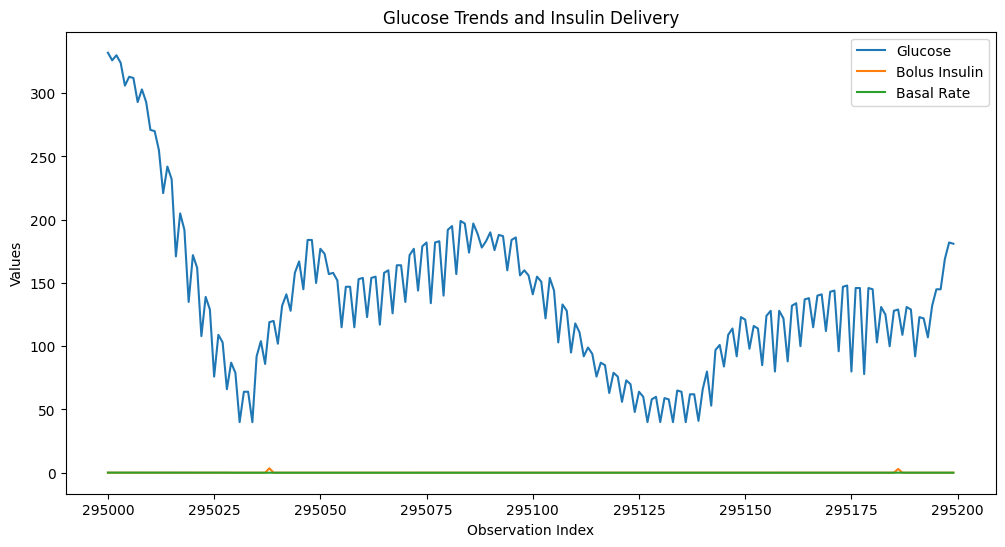

                         glucose  glucose_change  basal_rate  \
glucose                 1.000000        0.046514   -0.022562   
glucose_change          0.046514        1.000000   -0.006485   
basal_rate             -0.022562       -0.006485    1.000000   
bolus_volume_delivered  0.020113        0.028168    0.016666   

                        bolus_volume_delivered  
glucose                               0.020113  
glucose_change                        0.028168  
basal_rate                            0.016666  
bolus_volume_delivered                1.000000  


In [22]:
import matplotlib.pyplot as plt

# Calculate glucose trend/change
df['glucose_change'] = df['glucose'].diff()

# Select sample rows for visualization
sample = df.head(200)

plt.figure(figsize=(12,6))

plt.plot(sample['glucose'],
         label='Glucose')

plt.plot(sample['bolus_volume_delivered'],
         label='Bolus Insulin')

plt.plot(sample['basal_rate'],
         label='Basal Rate')

plt.title('Glucose Trends and Insulin Delivery')

plt.xlabel('Observation Index')
plt.ylabel('Values')

plt.legend()

plt.show()

# Correlation analysis
corr = df[['glucose',
           'glucose_change',
           'basal_rate',
           'bolus_volume_delivered']].corr()

print(corr)

“The glucose trend analysis revealed substantial glucose variability despite relatively stable basal insulin delivery and limited bolus insulin events. Correlation analysis showed very weak direct relationships between insulin biomarkers and glucose behavior, suggesting that glucose regulation is highly multifactorial and patient-specific. These findings support the need for personalized insulin adjustment strategies, continuous glucose monitoring, and multi-factor predictive healthcare systems to improve diabetes management and reduce glucose instability.”

5.How Can Prescriptive Analytics Help Prevent Hypoglycemia Events?

Biomarkers Chosen
glucose
glucose_change
bolus_volume_delivered
basal_rate
carb_input
heart_rate
Reasoning

Hypoglycemia occurs when blood glucose drops below normal levels, often due to:5.55

excessive insulin administration
delayed meals
low carbohydrate intake
sudden glucose decline

Prescriptive analytics can identify patterns leading to hypoglycemia by analyzing:

glucose trends
insulin delivery
carbohydrate intake
physiological responses

This enables healthcare providers to predict and prevent dangerous glucose drops before they occur.

Why This Analysis is Important
Helps reduce hypoglycemia risk
Improves patient safety
Supports proactive diabetes management
Enables real-time intervention systems
Helps optimize insulin dosing strategies
Recommended Chart

Risk Zone Scatter Plot

X-axis → Bolus Insulin Delivered
Y-axis → Glucose Level
Color → Hypoglycemia Risk Zone

This chart helps identify:

insulin levels associated with low glucose
high-risk patient clusters
overcorrection patterns

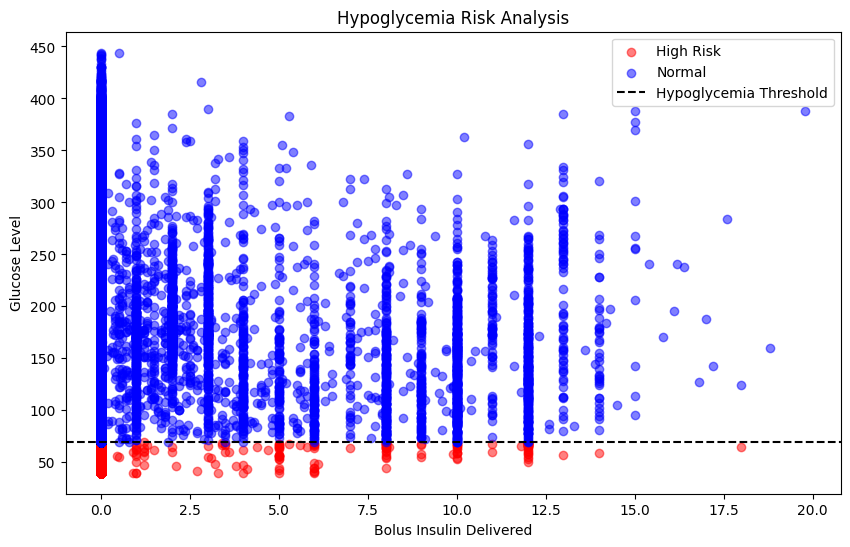

                         glucose  glucose_change  bolus_volume_delivered  \
glucose                 1.000000        0.046514                0.020113   
glucose_change          0.046514        1.000000                0.028168   
bolus_volume_delivered  0.020113        0.028168                1.000000   
basal_rate             -0.022562       -0.006485                0.016666   
carb_input             -0.001015        0.031033                0.169899   
heart_rate              0.098378       -0.013892                0.021530   

                        basal_rate  carb_input  heart_rate  
glucose                  -0.022562   -0.001015    0.098378  
glucose_change           -0.006485    0.031033   -0.013892  
bolus_volume_delivered    0.016666    0.169899    0.021530  
basal_rate                1.000000    0.026731   -0.069729  
carb_input                0.026731    1.000000    0.000282  
heart_rate               -0.069729    0.000282    1.000000  


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Create glucose change
df['glucose_change'] = df['glucose'].diff()

# Define hypoglycemia risk
df['hypo_risk'] = np.where(df['glucose'] < 70,
                           'High Risk',
                           'Normal')

# Plot
plt.figure(figsize=(10,6))

colors = {'High Risk':'red',
          'Normal':'blue'}

for risk in colors:
    subset = df[df['hypo_risk'] == risk]

    plt.scatter(
        subset['bolus_volume_delivered'],
        subset['glucose'],
        c=colors[risk],
        label=risk,
        alpha=0.5
    )

plt.axhline(70,
            color='black',
            linestyle='--',
            label='Hypoglycemia Threshold')

plt.xlabel('Bolus Insulin Delivered')
plt.ylabel('Glucose Level')

plt.title('Hypoglycemia Risk Analysis')

plt.legend()

plt.show()

# Correlation
corr = df[['glucose',
           'glucose_change',
           'bolus_volume_delivered',
           'basal_rate',
           'carb_input',
           'heart_rate']].corr()

print(corr)

“The hypoglycemia risk analysis revealed that low-glucose events occurred across a wide range of insulin doses, indicating that hypoglycemia cannot be explained by insulin delivery alone. Correlation analysis showed weak relationships between glucose and individual biomarkers, suggesting that glucose regulation is highly multifactorial and patient-specific. These findings highlight the importance of personalized insulin strategies, multi-biomarker predictive models, and continuous glucose monitoring systems to reduce hypoglycemia risk and improve diabetes management.”

6.What Is the Delayed Effect of Insulin on Future Glucose Levels?

Biomarkers Chosen

time
glucose
future_glucose
bolus_volume_delivered
basal_rate

Reasoning

Insulin does not immediately reduce glucose levels. After bolus insulin administration, glucose response may occur with a delay due to:

insulin absorption time
digestion rate
metabolic response
insulin sensitivity differences

Analyzing delayed glucose response helps determine:

whether insulin effects appear later
how long insulin takes to influence glucose
whether delayed hypoglycemia or hyperglycemia occurs
Why This Analysis is Important
Helps optimize insulin timing
Prevents delayed hypoglycemia
Supports predictive glucose monitoring
Improves personalized diabetes treatment
Helps identify insulin resistance patterns

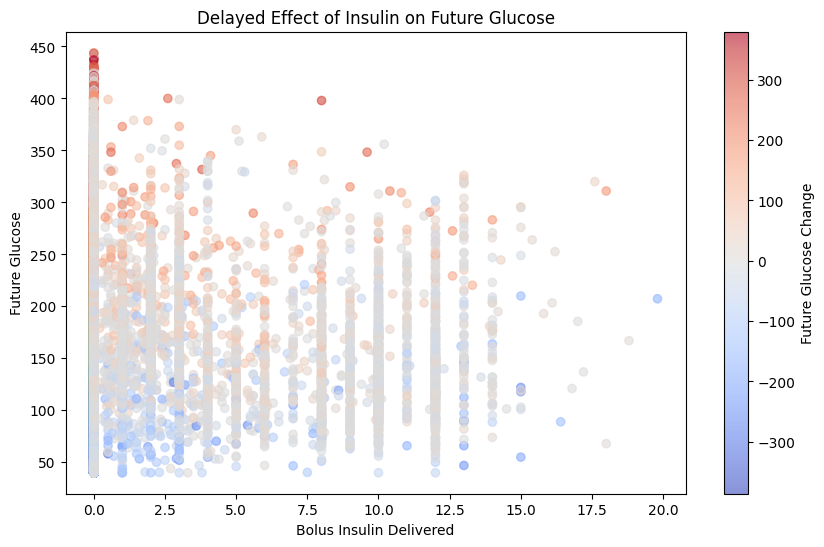

                        bolus_volume_delivered  basal_rate   glucose  \
bolus_volume_delivered                1.000000    0.016664  0.020112   
basal_rate                            0.016664    1.000000 -0.022572   
glucose                               0.020112   -0.022572  1.000000   
future_glucose                        0.019005    0.012437  0.635476   

                        future_glucose  
bolus_volume_delivered        0.019005  
basal_rate                    0.012437  
glucose                       0.635476  
future_glucose                1.000000  


In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Create future glucose (example: next 6 readings)
df['future_glucose'] = df['glucose'].shift(-6)

# Future glucose change
df['future_glucose_change'] = (
    df['future_glucose'] - df['glucose']
)

# Remove missing rows
lagged_df = df.dropna(subset=['future_glucose'])

# Plot
plt.figure(figsize=(10,6))

plt.scatter(
    lagged_df['bolus_volume_delivered'],
    lagged_df['future_glucose'],
    c=lagged_df['future_glucose_change'],
    cmap='coolwarm',
    alpha=0.6
)

plt.colorbar(label='Future Glucose Change')

plt.xlabel('Bolus Insulin Delivered')
plt.ylabel('Future Glucose')

plt.title('Delayed Effect of Insulin on Future Glucose')

plt.show()

# Correlation analysis
corr = lagged_df[[
    'bolus_volume_delivered',
    'basal_rate',
    'glucose',
    'future_glucose'
]].corr()

print(corr)

The event-based glucose response analysis revealed significant variability in glucose behavior following bolus insulin administration. While some patients experienced effective glucose reduction, others remained hyperglycemic despite higher insulin doses, suggesting possible insulin resistance or delayed insulin response. Additionally, extreme glucose reductions observed in certain patients may indicate hypoglycemia risk. These findings highlight the importance of personalized insulin dosing strategies and multi-factor predictive diabetes management systems.

7. Which Demographic Groups Show Higher Glucose Risk?

Biomarkers Chosen

Gender
Race
glucose

Reasoning

Different demographic groups may show different glucose patterns due to lifestyle and genetic factors.

Why This Analysis is Important

Supports targeted healthcare planning
Helps identify vulnerable populations

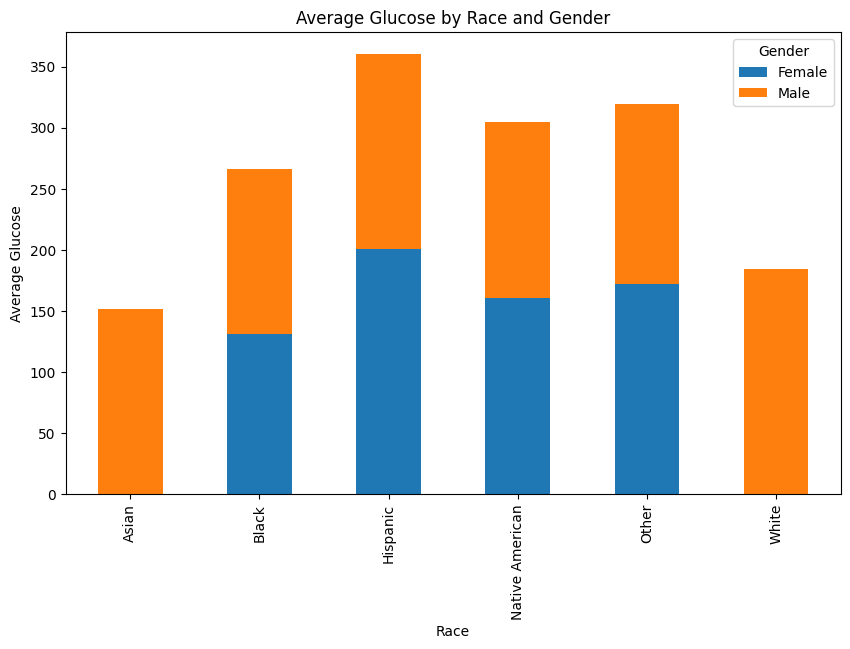

In [35]:
grouped = df.groupby(['Race','Gender'])['glucose'].mean().unstack()

grouped.plot(kind='bar', stacked=True, figsize=(10,6))

plt.ylabel('Average Glucose')
plt.title('Average Glucose by Race and Gender')

plt.show()